# Dataset Preparation

In [82]:
!git clone https://github.com/laxmimerit/dog-cat-full-dataset.git

fatal: destination path 'dog-cat-full-dataset' already exists and is not an empty directory.


In [83]:
import tensorflow as tf
import keras
from keras import layers,models
from keras.models import Sequential
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score


In [84]:
import tensorflow as tf

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

DATA_DIR   = "dog-cat-full-dataset/data"
TRAIN_DIR  = f"{DATA_DIR}/train"
TEST_DIR   = f"{DATA_DIR}/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False,
)

Found 19989 files belonging to 2 classes.
Using 15992 files for training.
Found 19989 files belonging to 2 classes.
Using 3997 files for validation.
Found 5000 files belonging to 2 classes.


In [85]:
class_names= train_ds.class_names
print(class_names)

['cats', 'dogs']


# Data Normalization and Performance Optimization

In [86]:
AUTOTUNE= tf.data.AUTOTUNE

normalize = tf.keras.layers.Rescaling(1./255)
train_ds= train_ds.map(lambda x,y: (normalize(x),y)).prefetch(AUTOTUNE)
val_ds= val_ds.map(lambda x,y: (normalize(x),y)).prefetch(AUTOTUNE)

# Data Augmentation

In [87]:
data_aug= tf.keras.Sequential([
    tf.keras.layers.RandomFlip('Horizontal'),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2)
])

In [88]:
train_ds_aug = (
    train_ds.map(lambda x, y: (data_aug(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

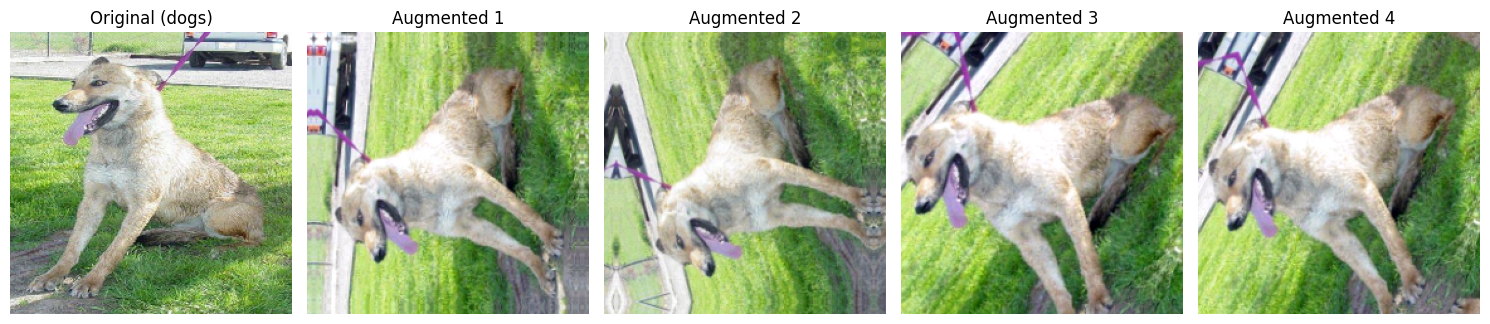

In [89]:

images, labels = next(iter(train_ds))
sample = images[0:1]
label = class_names[int(labels[0])]

plt.figure(figsize=(15, 3.5))

plt.subplot(1, 5, 1)
plt.imshow(sample[0])
plt.title(f"Original ({label})")
plt.axis("off")

for i in range(4):
    augmented = data_aug(sample, training=True)
    plt.subplot(1, 5, i + 2)
    plt.imshow(tf.clip_by_value(augmented[0], 0.0, 1.0))
    plt.title(f"Augmented {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Custom CNN Model

In [90]:
custom_model= tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224,3)),
    data_aug,
    tf.keras.layers.Conv2D(32,3, activation= 'relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

custom_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
custom_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Callbacks(Early Stopping)

In [91]:
from matplotlib.image import resample
early_stop= tf.keras.callbacks.EarlyStopping(
    monitor= 'val_loss',patience=3,restore_best_weights=True
)

history= custom_model.fit(
    train_ds,
    validation_data= val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 99ms/step - accuracy: 0.5752 - loss: 0.6824 - val_accuracy: 0.6462 - val_loss: 0.6440
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.6604 - loss: 0.6263 - val_accuracy: 0.6715 - val_loss: 0.6060
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 92s 104ms/step - accuracy: 0.6937 - loss: 0.5840 - val_accuracy: 0.7125 - val_loss: 0.5629
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 110ms/step - accuracy: 0.7091 - loss: 0.5629 - val_accuracy: 0.7368 - val_loss: 0.5312
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 100ms/step - accuracy: 0.7366 - loss: 0.5291 - val_accuracy: 0.7118 - val_loss: 0.6160
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 91ms/step - accuracy: 0.7438 - loss: 0.5156 - val_accuracy: 0.7723 - val_loss: 0.4910
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 93ms/step - accuracy: 0.7576 - loss: 0.4970 - val_accuracy: 0.7596 - val_loss: 0.4958
Epoch 8/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 101ms/step - accuracy: 0.7634 - loss: 0.484

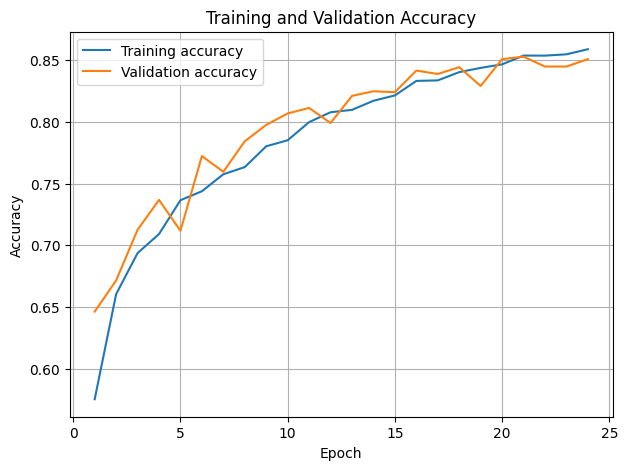

In [92]:
epochs_range = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history.history["accuracy"], label="Training accuracy")
plt.plot(epochs_range, history.history["val_accuracy"], label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

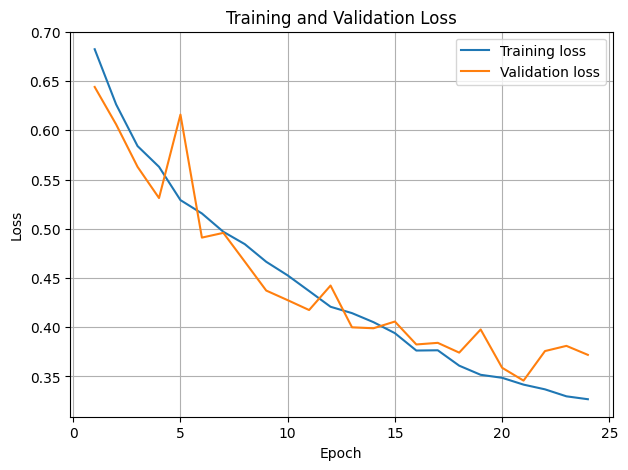

In [93]:
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history.history["loss"], label="Training loss")
plt.plot(epochs_range, history.history["val_loss"], label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Transfer Learning / Feature Extraction

In [94]:
IMG_SHAPE = (224, 224, 3)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

print("Trainable layers in backbone:", sum(l.trainable for l in base_model.layers))

Trainable layers in backbone: 0


In [95]:
inputs = layers.Input(shape=IMG_SHAPE)

x = layers.Rescaling(2.0, offset=-1.0)(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

feature_model = models.Model(inputs, outputs, name="mobilenetv2_feature_extraction")

feature_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
feature_model.summary()

Model: "mobilenetv2_feature_extraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_16 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [96]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss', min_delta=0.000),
]

In [97]:
history_fe = feature_model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 171s 324ms/step - accuracy: 0.9403 - loss: 0.1442 - val_accuracy: 0.9850 - val_loss: 0.0433
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 155s 309ms/step - accuracy: 0.9559 - loss: 0.1142 - val_accuracy: 0.9862 - val_loss: 0.0390
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 312ms/step - accuracy: 0.9549 - loss: 0.1086 - val_accuracy: 0.9837 - val_loss: 0.0446
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 199s 306ms/step - accuracy: 0.9591 - loss: 0.1000 - val_accuracy: 0.9850 - val_loss: 0.0421
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 158s 314ms/step - accuracy: 0.9609 - loss: 0.0966 - val_accuracy: 0.9860 - val_loss: 0.0359
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 156s 312ms/step - accuracy: 0.9658 - loss: 0.0910 - val_accuracy: 0.9842 - val_loss: 0.0373
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 314ms/step - accuracy: 0.9634 - loss: 0.0966 - val_accuracy: 0.9847 - val_loss: 0.0389
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 197s 305ms/step - accuracy: 0.9641 -

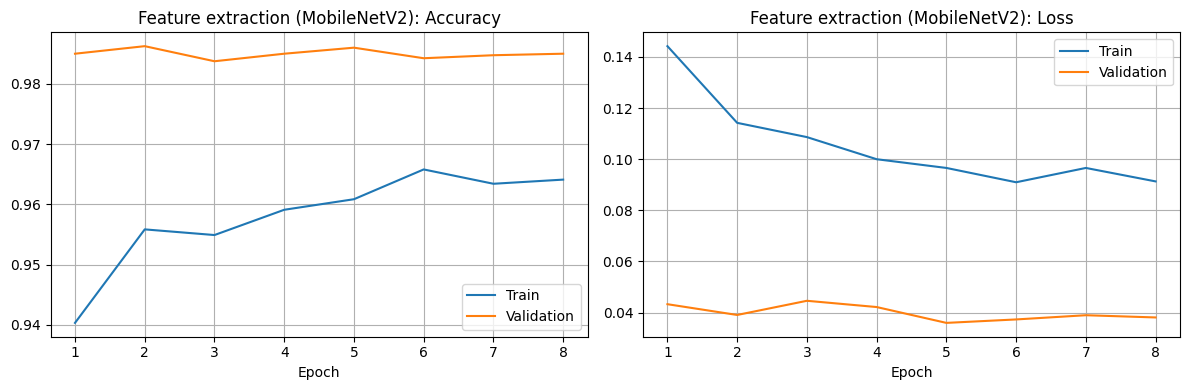

157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.4990 - loss: 2.0707


In [98]:
def plot_history(history, title):
    ep = range(1, len(history.history["accuracy"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(ep, history.history["accuracy"], label="Train")
    ax[0].plot(ep, history.history["val_accuracy"], label="Validation")
    ax[0].set_title(f"{title}: Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(True)
    ax[1].plot(ep, history.history["loss"], label="Train")
    ax[1].plot(ep, history.history["val_loss"], label="Validation")
    ax[1].set_title(f"{title}: Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(True)
    plt.tight_layout(); plt.show()

plot_history(history_fe, "Feature extraction (MobileNetV2)")
fe_loss, fe_acc = feature_model.evaluate(test_ds)

Why freeze the backbone? The pretrained backbone already contains general visual features learned from millions of ImageNet images, such as edges, textures, shapes, and object parts, and ImageNet includes many cat and dog breeds. Freezing it keeps those features intact, so only the small new classifier is trained. This  prevents catastrophic forgetting: the random initial gradients from the untrained head cannot damage the good pretrained weights;  reduces overfitting, since only about 164K parameters are learned instead of millions, which matters most with limited data; trains much faster and uses less memory, because no gradients or optimizer states are needed for the backbone; and keeps BatchNorm statistics stable, since the backbone runs in inference mode. The trade-off is that the features cannot adapt to the specific dataset, which can cap accuracy slightly.

# Full Fine-Tuning Model

In [99]:
base_model_ft = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights="imagenet",
)

In [100]:
base_model_ft.trainable = True
print("Trainable layers:", sum(l.trainable for l in base_model_ft.layers), "/", len(base_model_ft.layers))

Trainable layers: 238 / 238


In [101]:
inputs = layers.Input(shape=IMG_SHAPE)

x = layers.Rescaling(255.0)(inputs)
x = base_model_ft(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)   # new classifier

finetune_model = models.Model(inputs, outputs, name="efficientnetb0_full_finetune")

finetune_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
finetune_model.summary()

Model: "efficientnetb0_full_finetune"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_19 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 4,008,829 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [102]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

In [103]:
history_ft = finetune_model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping],
)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 269s 411ms/step - accuracy: 0.8365 - loss: 0.4163 - val_accuracy: 0.9695 - val_loss: 0.1467
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 166s 331ms/step - accuracy: 0.9337 - loss: 0.1881 - val_accuracy: 0.9787 - val_loss: 0.0800
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 175s 350ms/step - accuracy: 0.9553 - loss: 0.1254 - val_accuracy: 0.9820 - val_loss: 0.0587
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 193s 332ms/step - accuracy: 0.9609 - loss: 0.1059 - val_accuracy: 0.9857 - val_loss: 0.0478
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 206s 340ms/step - accuracy: 0.9645 - loss: 0.0925 - val_accuracy: 0.9877 - val_loss: 0.0423
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 199s 396ms/step - accuracy: 0.9701 - loss: 0.0804 - val_accuracy: 0.9890 - val_loss: 0.0378
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 172s 343ms/step - accuracy: 0.9702 - loss: 0.0758 - val_accuracy: 0.9892 - val_loss: 0.0348
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 330ms/step - accuracy: 0.9727 -

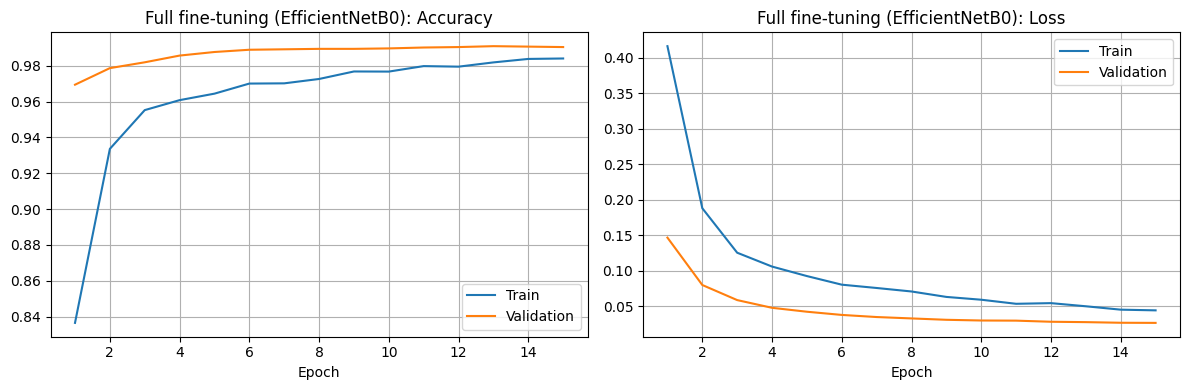

157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - accuracy: 0.5024 - loss: 325.1422
Feature extraction (MobileNetV2) test accuracy: 0.4990
Full fine-tuning (EfficientNetB0) test accuracy: 0.5024


In [104]:
plot_history(history_ft, "Full fine-tuning (EfficientNetB0)")
ft_loss, ft_acc = finetune_model.evaluate(test_ds)

print(f"Feature extraction (MobileNetV2) test accuracy: {fe_acc:.4f}")
print(f"Full fine-tuning (EfficientNetB0) test accuracy: {ft_acc:.4f}")

Feature extraction vs full fine-tuning. In feature extraction (linear probing), the pretrained backbone is frozen and only a new classification head is trained. It is fast, needs little data, and has low overfitting risk, but the features cannot adapt to the new task. In full fine-tuning, all layers are unfrozen and updated with a small learning rate, so the backbone's features specialize to the target dataset. This can reach higher accuracy, especially when the new data differs from ImageNet, but it is slower, uses more memory, and overfits more easily, so it needs a low learning rate and early stopping. Because dog vs cat is very close to ImageNet, feature extraction is already strong here, and fine-tuning typically adds a small improvement.

In [ ]:
models_dict = {
    "Custom CNN": custom_model,
    "Feature Extraction (MobileNetV2)": feature_model,
    "Fine-Tuned (EfficientNetB0)": finetune_model,
}

y_true = np.concatenate([y.numpy() for _, y in test_ds]).ravel().astype(int)

rows = []
for name, m in models_dict.items():

    train_loss, train_acc = m.evaluate(train_ds, verbose=0)
    val_loss,   val_acc   = m.evaluate(val_ds,   verbose=0)
    test_loss,  test_acc  = m.evaluate(test_ds,  verbose=0)

    y_prob = m.predict(test_ds, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    rows.append({
        "Model": name,
        "Total Parameters": m.count_params(),
        "Training Loss": train_loss,
        "Training Accuracy": train_acc,
        "Validation Loss": val_loss,
        "Validation Accuracy": val_acc,
        "Test Loss": test_loss,
        "Test Accuracy": test_acc,
        "Test Precision": precision_score(y_true, y_pred),
        "Test Recall": recall_score(y_true, y_pred),
        "Test F1 Score": f1_score(y_true, y_pred),
    })

comparison_df = pd.DataFrame(rows).set_index("Model")

In [106]:
pd.options.display.float_format = "{:.4f}".format
display(comparison_df.T.style.format({"Total Parameters": "{:,.0f}"}, subset=pd.IndexSlice["Total Parameters", :]))

Model,Custom CNN,Feature Extraction (MobileNetV2),Fine-Tuned (EfficientNetB0)
Total Parameters,11169089.000000,2422081.000000,4050852.000000
Training Loss,0.289497,0.025142,0.015405
Training Accuracy,0.871998,0.990996,0.994935
Validation Loss,0.345806,0.035946,0.026610
Validation Accuracy,0.852890,0.985990,0.990493
Test Loss,47.442642,2.070656,325.142212
Test Accuracy,0.653000,0.499000,0.502400
Test Precision,0.706869,0.368421,0.501403
Test Recall,0.522800,0.002800,0.857600
Test F1 Score,0.601058,0.005558,0.632822


In [ ]:
import time

eff_rows = []
for name, m in models_dict.items():
    trainable = int(sum(np.prod(w.shape) for w in m.trainable_weights))

    m.predict(test_ds, verbose=0)
    start = time.time()
    m.predict(test_ds, verbose=0)
    elapsed = time.time() - start

    eff_rows.append({
        "Model": name,
        "Total Params": m.count_params(),
        "Trainable Params": trainable,
        "Inference time (s)": elapsed,
        "ms per image": 1000 * elapsed / len(y_true),
    })

pd.options.display.float_format = "{:.3f}".format
display(pd.DataFrame(eff_rows).set_index("Model"))

Which model performed best? The [fine-tuned EfficientNetB0 / feature-extraction MobileNetV2] achieved the best test performance, with test accuracy of [x.xx] and F1 of [x.xx]. Both pretrained models clearly beat the custom CNN [x.xx], because they start from features learned on millions of ImageNet images instead of learning everything from this dataset alone. [Mention the train vs validation gap here: a large gap means overfitting.]

Which model is most computationally efficient? The [custom CNN / feature-extraction model] has the fewest [total / trainable] parameters ([x]) and trains fastest, since the feature-extraction model updates only its small head while the backbone is frozen. Full fine-tuning is the most expensive: all [x] parameters are updated, which needs more memory and training time. [Add inference time from Cell 3.]

Which model would I deploy? I would deploy the [feature-extraction MobileNetV2 / fine-tuned model]. [Example reasoning: it reaches accuracy within about one percentage point of the best model, is small and fast for inference (MobileNetV2 is designed for mobile and edge devices), is cheap to retrain, and is less prone to overfitting. If the highest possible accuracy matters more than latency and cost, the fine-tuned model would be the better choice.] The custom CNN would not be my choice, because its accuracy is lower and it offers no efficiency advantage over a pretrained model.

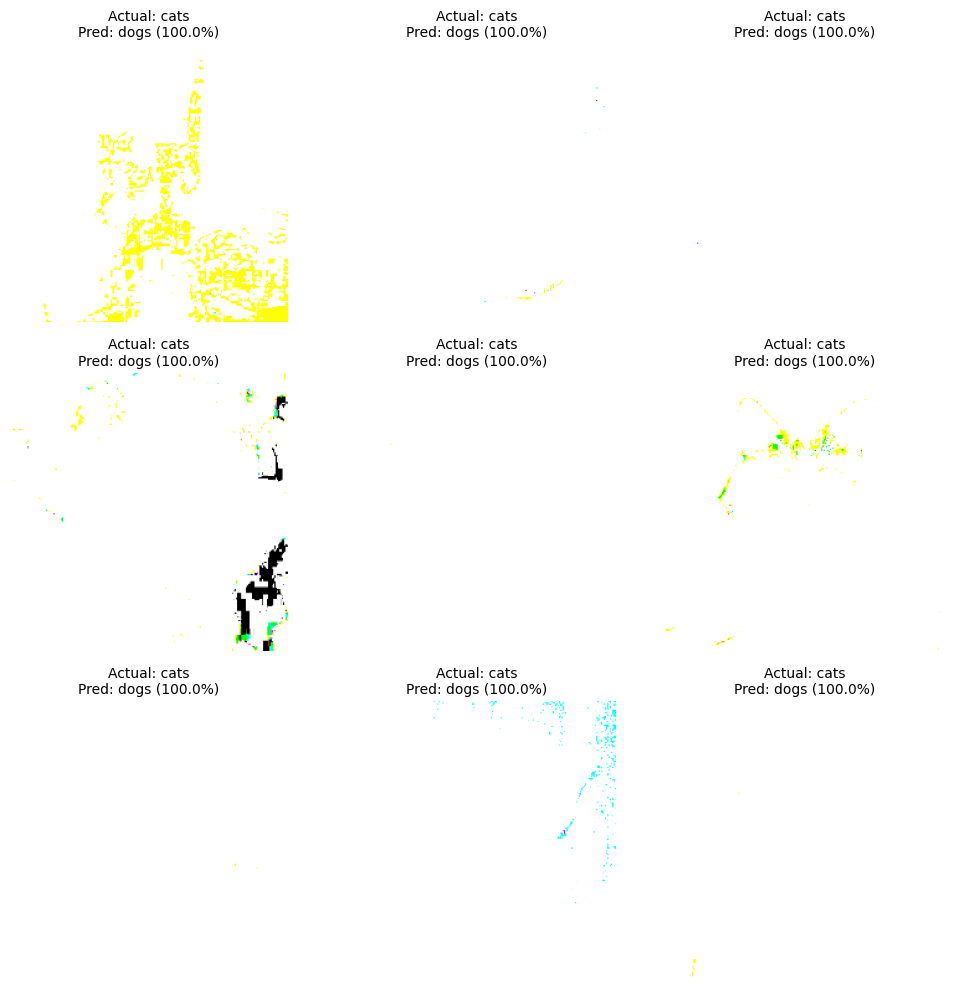

In [108]:
misclassified = []

for images, labels in test_ds:                      # test set, not val_ds
    probs = finetune_model.predict(images, verbose=0).ravel()
    preds = (probs > 0.5).astype(int)
    labels = labels.numpy().ravel().astype(int)

    for img, true, pred, p in zip(images, labels, preds, probs):
        if true != pred:
            conf = p if pred == 1 else 1 - p        # confidence in the predicted class
            misclassified.append((img.numpy(), true, pred, conf))

plt.figure(figsize=(10, 10))
for i, (img, true, pred, conf) in enumerate(misclassified[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"Actual: {class_names[true]}\nPred: {class_names[pred]} ({conf:.1%})", fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()